## Logistic Regression from Scratch

In this exercise, you will implement a logistic regression model from scratch and train it on a synthetic binary classification dataset. <br>
Fill in the code in the cells below.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)  # For reproducibility

### 1. Dataset Generation

#### 1.1 Create a synthetic binary classification dataset

In [2]:
from sklearn.datasets import make_classification

X, y = make_classification(
    n_samples=200,           # Total number of points
    n_features=2,            # 2 features for 2D visualization
    n_informative=2,         # Both features are informative
    n_redundant=0,           # No redundant features
    n_clusters_per_class=1,  # One cluster per class
    class_sep=2.0,           # Controls the separability between classes    
    random_state=42          # For reproducibility
)

#### 1.2 Plot the data

In [3]:
def plot_data(X, y):
    """Plots a binary classifiation dataset using a scatter plot with points colored by class, 
       labeled as 'Class 0' and 'Class 1'.
    """
    plt.scatter(X[y == 0, 0], X[y == 0, 1], c='blue', label='Class 0', edgecolors='k', alpha=0.7)
    plt.scatter(X[y == 1, 0], X[y == 1, 1], c='red', label='Class 1', edgecolors='k', alpha=0.7)
    plt.xlabel('Feature 1')
    plt.ylabel('Feature 2')
    plt.legend()
    plt.title('Binary Classification Dataset')

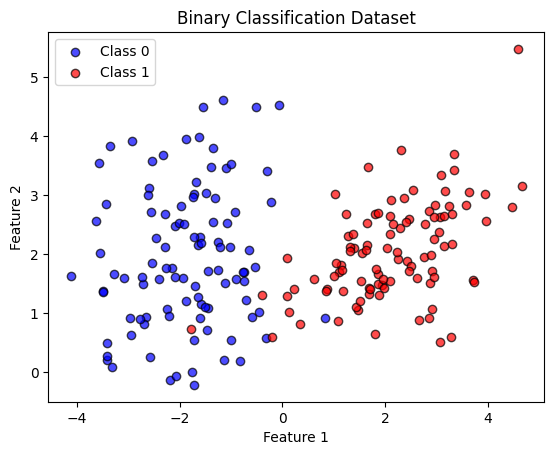

In [4]:
plot_data(X, y)

#### 1.3 Append a column of ones 

In [5]:
# Add a column to X representing the bias term
n = len(X)
X_b = np.c_[np.ones((n, 1)), X]

### 2. Model Implementation

#### 3.1 Sigmoid function

In [6]:
def sigmoid(z):
    """Computes the sigmoid of z (z can be a scalar or a vector)."""
    return 1 / (1 + np.exp(-z))

In [7]:
test = np.array([0, 0.5, 1])
print(np.round(sigmoid(test), 4))  # Expected output: [0.5    0.6225 0.7311]

[0.5    0.6225 0.7311]


#### 3.2 Cost function and gradient

In [8]:
def cost_function(X, y, w):    
    """
    Computes the cost and gradient for logistic regression.
    
    Args:        
        X: Feature matrix (with bias term)
        y: Target labels
        w: Parameter vector (weights)
    Returns:
        cost: Value of the logistic regression cost function (average log loss)
        grad: Gradient of the cost function with respect to the parameters
    """    
    n = len(y)
    p = sigmoid(X @ w)
    eps = 1e-15  # to avoid log(0)
    cost = -np.mean(y * np.log(p + eps) + (1 - y) * np.log(1 - p + eps))
    grad = (1 / n) * (X.T @ (p - y))
    return cost, grad

In [9]:
# Test the function
w = np.zeros(shape=X_b.shape[1])
cost, grad = cost_function(X_b, y, w)

print('Cost:', np.round(cost, 4))  # Expected output: 0.6931
print('Gradient:', np.round(grad, 4))  # Expected output: [-0 -0.9989 -0.0212]

Cost: 0.6931
Gradient: [ 0.     -0.9989 -0.0212]


#### 3.3 Model training using gradient descent

In [10]:
def optimize_model(X, y, alpha=0.1, max_iter=1000, tol=0.0001):
    """
    Optimize the model parameters using batch gradient descent.
    
    Args:
        X: Feature matrix (with bias term)
        y: Target labels
        alpha: Learning rate
        max_iter: Maximum number of iterations
        tol: Tolerance for the stopping criterion
    Returns:
        w: The optimized parameters
        cost_history: List of cost values at each iteration
    """
    w = np.zeros(X.shape[1])
    cost_history = []
    
    for i in range(max_iter):
        cost, grad = cost_function(X, y, w)
        cost_history.append(cost)
        w = w - alpha * grad
        if i > 0 and abs(cost_history[-2] - cost_history[-1]) < tol:
            break
    
    return w, cost_history

In [11]:
w_opt, cost_history = optimize_model(X_b, y)
print('Optimized weights:', np.round(w_opt, 4))  # Expected output: [ 0.1332  2.0431 -0.1672]

Optimized weights: [ 0.0966  2.0446 -0.1571]


#### 3.4 Plot the learning curve

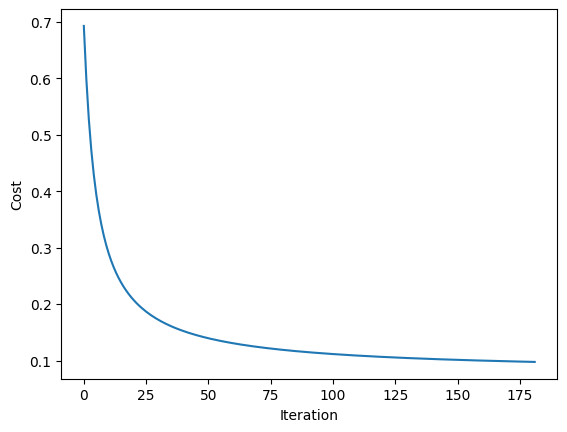

In [12]:
plt.plot(cost_history)
plt.xlabel('Iteration')
plt.ylabel('Cost');

### 4. Making Predictions

#### 4.1 Make Probabilistic Predictions

In [13]:
def predict_prob(X, w_opt):
    """Compute the probability of the positive class for samples in X."""
    X = np.array(X)
    X_b = np.c_[np.ones((X.shape[0], 1)), X]
    p = sigmoid(X_b @ w_opt)
    return p

In [14]:
prob = predict_prob([[0, 0]], w_opt)
print('Probability of class 1:', np.round(prob[0], 4))  # Expected output: 0.5332

Probability of class 1: 0.5241


#### 4.2 Predict Final Labels

In [15]:
def predict(X, w_opt, threshold=0.5):
    """Classify samples as 0 or 1 based on the given threshold."""
    p = predict_prob(X, w_opt)
    y_pred = (p >= threshold).astype(int)
    return y_pred

In [16]:
y_pred = predict([[-1, -1], [0, 0], [1, 1]], w_opt)
print(y_pred)  # Expected output: array([0, 1, 1])

[0 1 1]


### 5. Model Evaluation

#### 5.1 Compute model accuracy

In [17]:
def evaluate_model(X, y, w_opt):
    """Calculate the model's accuracy on the given dataset."""
    y_pred = predict(X, w_opt)
    accuracy = np.mean(y_pred == y)
    return accuracy

In [18]:
accuracy = evaluate_model(X, y, w_opt)
print(f'Accuracy: {accuracy:.4f}')  # Expected output: 0.9750

Accuracy: 0.9750


#### 5.2 Plot decision boundary

In [19]:
def plot_decision_boundary(X, y, w_opt):
    """Plot the decision boundary for a 2D logistic regression classifier."""
    x1_min, x1_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    # Decision boundary: w0 + w1*x1 + w2*x2 = 0  =>  x2 = -(w0 + w1*x1) / w2
    x1_vals = np.array([x1_min, x1_max])
    x2_vals = -(w_opt[0] + w_opt[1] * x1_vals) / w_opt[2]
    plt.plot(x1_vals, x2_vals, 'k-', linewidth=2, label='Decision Boundary')
    plt.legend()

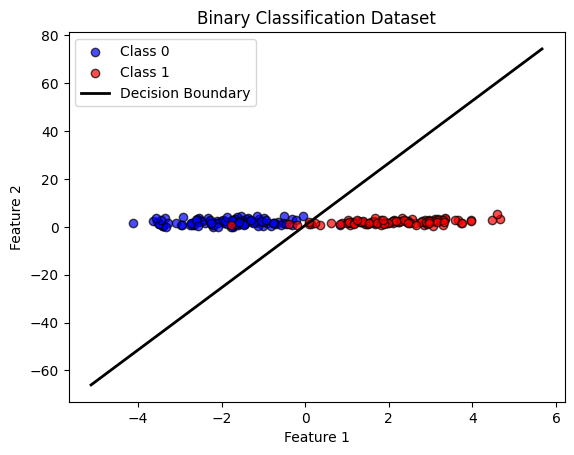

In [20]:
plot_data(X, y)
plot_decision_boundary(X, y, w_opt)